# Grape Disease Classification - Deep Learning Pipeline

This notebook mirrors the potato workflow, adapted for grape disease classes:
- Black Rot
- Downy Mildew
- Healthy
- Powdery Mildew

Pipeline:
1. Setup and imports
2. Data transforms
3. Dataset split (70/15/15)
4. Class weighting
5. MobileNetV2 transfer learning
6. Phase-1 training (frozen backbone)
7. Phase-2 fine-tuning
8. Evaluation + confusion matrix
9. Inference helper

## Cell 1: Imports and device

**What:** Import the libraries and select the compute device for training and inference.

**Why:** This initializes the tools and hardware context used by the rest of the notebook.

**Cons:** Environment issues here can block everything that follows.


In [1]:
# Cell 1: Imports and device
import copy
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

PyTorch: 2.5.1+cu121
Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2: Transforms

**What:** Define the image transforms for training and validation.

**Why:** We standardize inputs and add augmentation so the model can generalize better.

**Cons:** Heavy augmentation can sometimes distort important disease patterns.


In [2]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

normal_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

heavy_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomPerspective(distortion_scale=0.3, p=0.4),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

print("Transforms ready")

Transforms ready


## Cell 3: Dataset Loading

**What:** Load the crop dataset and split it into train, validation, and test sets.

**Why:** This gives us clean partitions for learning, tuning, and final evaluation.

**Cons:** A random split can still introduce mild class imbalance or sample bias.


In [3]:
DATASET_PATH = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/grape"

full_dataset = ImageFolder(DATASET_PATH)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Total images: {len(full_dataset)}")

n = len(full_dataset)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42)
)

class GrapeDataset(Dataset):
    def __init__(self, subset, class_names, normal_transform, heavy_transform, val_transform, is_train=True):
        self.subset = subset
        self.is_train = is_train
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform
        self.val_transform = val_transform
        self.healthy_idx = next((i for i, n in enumerate(class_names) if "healthy" in n.lower()), None)

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if not self.is_train:
            image = self.val_transform(image)
        elif self.healthy_idx is not None and label == self.healthy_idx:
            image = self.heavy_transform(image)
        else:
            image = self.normal_transform(image)
        return image, label

train_data = GrapeDataset(train_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=True)
val_data = GrapeDataset(val_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=False)
test_data = GrapeDataset(test_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=False)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

with open("grape_classes.json", "w") as f:
    json.dump(class_names, f)

print(f"Split -> Train: {n_train}, Val: {n_val}, Test: {n_test}")
print("DataLoaders ready")

Classes (4): ['Black Rot', 'Downy Mildew', 'Healthy', 'Powdery Mildew']
Total images: 4951
Split -> Train: 3465, Val: 742, Test: 744
DataLoaders ready


## Cell 4: Class Weights

**What:** Compute class weights from the training labels.

**Why:** We reduce bias toward classes with more images during optimization.

**Cons:** If weights are too strong, the model can overcompensate for minority classes.


In [4]:
train_labels = [full_dataset.targets[i] for i in train_ds.indices]
label_counts = Counter(train_labels)

print("Class distribution (train):")
for i, name in enumerate(class_names):
    print(f"  {name}: {label_counts[i]}")

total_train = len(train_labels)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print("Class-weighted + label-smoothed loss ready")

Class distribution (train):
  Black Rot: 1307
  Downy Mildew: 681
  Healthy: 1198
  Powdery Mildew: 279
Class-weighted + label-smoothed loss ready


## Cell 5: ResNet18 Setup

**What:** Load ResNet18 and replace the classifier for the crop disease classes.

**Why:** Transfer learning gives us a strong pretrained backbone with less training time.

**Cons:** A frozen backbone may miss crop-specific visual features at first.


In [5]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
for p in model.fc.parameters():
    p.requires_grad = True
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total_params:,}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
print("Model and optimizer ready")

Trainable: 2,052 / 11,178,564
Model and optimizer ready


## Cell 6: Augmentation Helpers

**What:** Add mixup, cutmix, and test-time augmentation helper logic.

**Why:** These techniques improve robustness and help the model generalize beyond seen samples.

**Cons:** They add training complexity and can make results harder to interpret.


In [6]:
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIXUP_PROB = 0.4
CUTMIX_PROB = 0.3
ENABLE_TTA = True
TTA_MODES = ("none", "hflip", "vflip", "rot90", "rot270")

def _rand_bbox(size, lam):
    h, w = size[2], size[3]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(w * cut_ratio)
    cut_h = int(h * cut_ratio)

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    x1 = np.clip(cx - cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y2 = np.clip(cy + cut_h // 2, 0, h)
    return x1, y1, x2, y2

def _apply_mixup(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def _apply_cutmix(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    labels_a, labels_b = labels, labels[idx]
    x1, y1, x2, y2 = _rand_bbox(images.size(), lam)
    images[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    patch = (x2 - x1) * (y2 - y1)
    lam = 1.0 - patch / float(images.size(-1) * images.size(-2))
    return images, labels_a, labels_b, lam

def _tta_logits(model, images):
    logits = []
    for mode in TTA_MODES:
        if mode == "none":
            aug = images
        elif mode == "hflip":
            aug = torch.flip(images, dims=[3])
        elif mode == "vflip":
            aug = torch.flip(images, dims=[2])
        elif mode == "rot90":
            aug = torch.rot90(images, 1, dims=[2, 3])
        elif mode == "rot270":
            aug = torch.rot90(images, 3, dims=[2, 3])
        else:
            raise ValueError(f"Unknown TTA mode: {mode}")
        logits.append(model(aug))
    return torch.stack(logits, dim=0).mean(dim=0)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0.0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        use_mixed = False
        labels_a, labels_b, lam = labels, labels, 1.0
        r = np.random.rand()
        if r < MIXUP_PROB:
            images, labels_a, labels_b, lam = _apply_mixup(images, labels, MIXUP_ALPHA)
            use_mixed = True
        elif r < MIXUP_PROB + CUTMIX_PROB:
            images, labels_a, labels_b, lam = _apply_cutmix(images, labels, CUTMIX_ALPHA)
            use_mixed = True

        outputs = model(images)
        if use_mixed:
            loss = lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        if use_mixed:
            correct += lam * (preds == labels_a).sum().item() + (1.0 - lam) * (preds == labels_b).sum().item()
        else:
            correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

print("train_epoch and eval_epoch ready (MixUp/CutMix enabled)")

train_epoch and eval_epoch ready (MixUp/CutMix enabled)


## Cell 7: Phase 1 Training (Frozen Base)

**What:** Train phase 1 with the backbone frozen and only the head learning.

**Why:** This safely adapts the classifier before fine-tuning deeper layers.

**Cons:** Accuracy may plateau early because most of the network stays unchanged.


In [7]:
EPOCHS_PHASE1 = 10
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
patience_count = 0
phase1_epochs_run = 0

for epoch in range(EPOCHS_PHASE1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    phase1_epochs_run += 1

    print(f"P1 Epoch {epoch+1:02d}/{EPOCHS_PHASE1} | Tr Acc: {tr_acc*100:.2f}% | Val Acc: {vl_acc*100:.2f}%")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), "grape_phase1.pt")
    else:
        patience_count += 1
        if patience_count >= 3:
            print("Early stopping in phase 1")
            break

model.load_state_dict(torch.load("grape_phase1.pt", weights_only=True))
print(f"Best phase-1 val acc: {best_val_acc*100:.2f}%")

P1 Epoch 01/10 | Tr Acc: 75.83% | Val Acc: 95.69%
P1 Epoch 02/10 | Tr Acc: 83.74% | Val Acc: 97.04%
P1 Epoch 03/10 | Tr Acc: 85.01% | Val Acc: 98.25%
P1 Epoch 04/10 | Tr Acc: 89.72% | Val Acc: 98.25%
P1 Epoch 05/10 | Tr Acc: 85.44% | Val Acc: 97.57%
P1 Epoch 06/10 | Tr Acc: 86.58% | Val Acc: 98.52%
P1 Epoch 07/10 | Tr Acc: 85.73% | Val Acc: 98.52%
P1 Epoch 08/10 | Tr Acc: 86.20% | Val Acc: 98.92%
P1 Epoch 09/10 | Tr Acc: 87.68% | Val Acc: 99.06%
P1 Epoch 10/10 | Tr Acc: 88.60% | Val Acc: 98.92%
Best phase-1 val acc: 99.06%


## Cell 8: Phase 2 Fine-tuning

**What:** Unfreeze deeper layers and run phase 2 fine-tuning.

**Why:** This lets the pretrained features adapt more closely to crop disease patterns.

**Cons:** Fine-tuning can overfit if the learning rate or patience is not controlled well.


In [8]:
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=1)

EPOCHS_PHASE2 = 5
best_val_acc2 = 0.0
patience_count2 = 0

for epoch in range(EPOCHS_PHASE2):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer2, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler2.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"P2 Epoch {epoch+1:02d}/{EPOCHS_PHASE2} | Tr Acc: {tr_acc*100:.2f}% | Val Acc: {vl_acc*100:.2f}%")

    if vl_acc > best_val_acc2:
        best_val_acc2 = vl_acc
        patience_count2 = 0
        torch.save(model.state_dict(), "grape_final_model.pt")
    else:
        patience_count2 += 1
        if patience_count2 >= 2:
            print("Early stopping in phase 2")
            break

model.load_state_dict(torch.load("grape_final_model.pt", weights_only=True))
print(f"Best phase-2 val acc: {best_val_acc2*100:.2f}%")

P2 Epoch 01/5 | Tr Acc: 87.13% | Val Acc: 98.92%
P2 Epoch 02/5 | Tr Acc: 87.27% | Val Acc: 99.06%
P2 Epoch 03/5 | Tr Acc: 89.28% | Val Acc: 98.92%
P2 Epoch 04/5 | Tr Acc: 87.95% | Val Acc: 98.38%
Early stopping in phase 2
Best phase-2 val acc: 99.06%


## Cell 9: Training Plot

**What:** Plot training and validation accuracy and loss across the training phases.

**Why:** The curves help us quickly judge learning progress and spot instability.

**Cons:** Good curves do not always guarantee the model will generalize on unseen data.


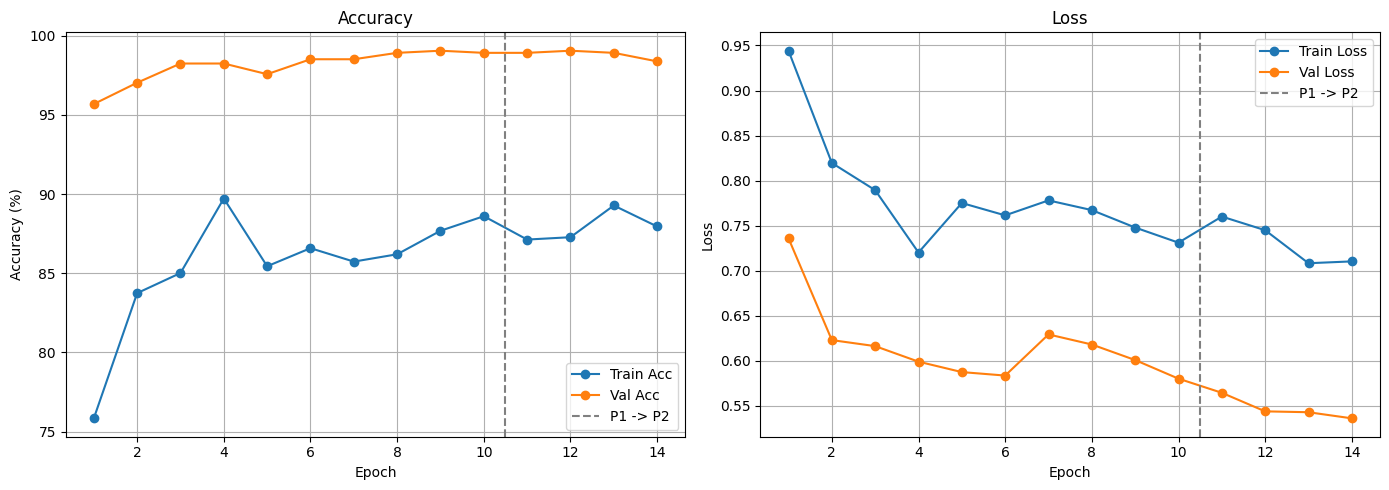

Saved grape_training_plot.png


In [9]:
all_epochs = list(range(1, len(history["train_acc"]) + 1))
boundary = phase1_epochs_run + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_epochs, [x * 100 for x in history["train_acc"]], marker="o", label="Train Acc")
ax1.plot(all_epochs, [x * 100 for x in history["val_acc"]], marker="o", label="Val Acc")
ax1.axvline(x=boundary, color="gray", linestyle="--", label="P1 -> P2")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.grid(True)
ax1.legend()

ax2.plot(all_epochs, history["train_loss"], marker="o", label="Train Loss")
ax2.plot(all_epochs, history["val_loss"], marker="o", label="Val Loss")
ax2.axvline(x=boundary, color="gray", linestyle="--", label="P1 -> P2")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
print("Saved grape_training_plot.png")

## Cell 10: Test Evaluation + Confusion Matrix

**What:** Evaluate the trained model on the test set and build a confusion matrix.

**Why:** We measure final performance and see which classes are being confused.

**Cons:** Test metrics summarize outcomes but do not explain the visual reason behind mistakes.


Classification report:
                precision    recall  f1-score   support

     Black Rot       1.00      1.00      1.00       302
  Downy Mildew       0.99      0.99      0.99       144
       Healthy       1.00      1.00      1.00       234
Powdery Mildew       0.97      0.98      0.98        64

      accuracy                           1.00       744
     macro avg       0.99      0.99      0.99       744
  weighted avg       1.00      1.00      1.00       744



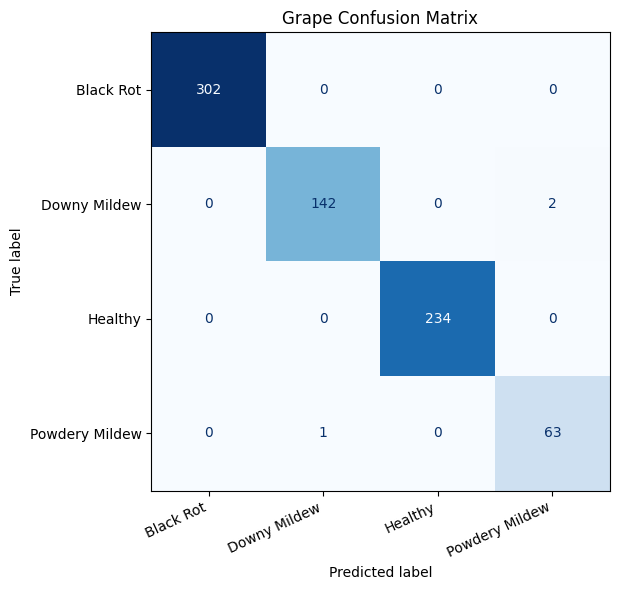

Saved grape_confusion_matrix.png | TTA=ON


In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        if ENABLE_TTA:
            outputs = _tta_logits(model, images)
        else:
            outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=class_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Grape Confusion Matrix")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
print(f"Saved grape_confusion_matrix.png | TTA={'ON' if ENABLE_TTA else 'OFF'}")

## Cell 11: Explainability and Spread Analysis

**What:** Add leaf segmentation, Grad-CAM, and spread estimation utilities.

**Why:** These steps make predictions more interpretable and estimate how much of the leaf is affected.

**Cons:** Image-processing heuristics can be sensitive to lighting, background, and leaf orientation.


In [11]:
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchcam.methods import GradCAMpp

# ─────────────────────────────────────────────────────────────
# LAYER 1: Leaf Segmentation — GrabCut + HSV fallback chain
# ─────────────────────────────────────────────────────────────
def segment_leaf(image_np):
    h, w = image_np.shape[:2]
    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

    # Loose HSV — catches green, brown, yellow, dark leaf tissue
    masks = [
        cv2.inRange(hsv, np.array([15, 20, 20]),  np.array([95, 255, 255])),   # green + yellow
        cv2.inRange(hsv, np.array([5,  30, 30]),  np.array([25, 255, 200])),   # brown
        cv2.inRange(hsv, np.array([0,  0,  20]),  np.array([180, 60, 80])),    # dark necrotic
    ]
    loose_mask = masks[0]
    for m in masks[1:]:
        loose_mask = cv2.bitwise_or(loose_mask, m)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    loose_mask = cv2.morphologyEx(loose_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    loose_mask = cv2.morphologyEx(loose_mask, cv2.MORPH_OPEN,  kernel, iterations=2)

    # Find bounding box of largest region for adaptive GrabCut rect
    contours, _ = cv2.findContours(loose_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    seg_path = "adaptive"  # track which path was used
    if contours and cv2.contourArea(max(contours, key=cv2.contourArea)) > 0.20 * h * w:
        x, y, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
        pad = 10
        x = max(0, x - pad)
        y = max(0, y - pad)
        bw = min(w - x, bw + 2 * pad)
        bh = min(h - y, bh + 2 * pad)
        rect = (x, y, bw, bh)
    else:
        # Fallback 1 — fixed center rect
        rect = (28, 28, 168, 168)
        seg_path = "fixed_center"

    # GrabCut
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    mask_gc = np.zeros((h, w), np.uint8)
    try:
        cv2.grabCut(image_np, mask_gc, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        leaf_mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 1).astype(np.uint8)
    except Exception:
        leaf_mask = np.ones((h, w), np.uint8)
        seg_path = "grabcut_failed"

    # Morphological closing to fill holes from diseased patches
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Fallback 2 — if result still too small
    if leaf_mask.sum() < 0.10 * h * w:
        leaf_mask = np.ones((h, w), np.uint8)
        seg_path = "full_image_uncertain"

    return leaf_mask, seg_path


# ─────────────────────────────────────────────────────────────
# LAYER 2: GradCAM++ — dynamic target layer selection
# ─────────────────────────────────────────────────────────────
def _resolve_gradcam_target_layer(model):
    # Prefer last block in feature extractors (MobileNet/EfficientNet style)
    if hasattr(model, "features"):
        for idx in range(len(model.features) - 1, -1, -1):
            block = model.features[idx]
            if any(isinstance(m, torch.nn.Conv2d) for m in block.modules()):
                return f"features.{idx}"

    # ResNet family fallback
    if hasattr(model, "layer4"):
        return "layer4"

    # Generic fallback: last Conv2d found in named modules
    last_conv_name = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv_name = name
    if last_conv_name is not None:
        return last_conv_name

    raise ValueError("No Conv2d layer found for Grad-CAM target layer")


def get_gradcam_mask(model, input_tensor, pred_class):
    target_layer = _resolve_gradcam_target_layer(model)
    cam_extractor = GradCAMpp(model, target_layer=target_layer)
    model.eval()
    out = model(input_tensor.unsqueeze(0).to(device))
    cam = cam_extractor(pred_class, out)[0]
    cam_np = cam.squeeze().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() + 1e-8)
    cam_resized = cv2.resize(cam_np, (224, 224))
    cam_extractor.remove_hooks()
    return cam_resized


# ─────────────────────────────────────────────────────────────
# LAYER 3: Disease Color Detection
# ─────────────────────────────────────────────────────────────
def detect_disease_pixels(image_np):
    # CLAHE first — normalize lighting
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    image_np = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

    brown_mask = cv2.inRange(hsv, np.array([5, 40, 40]), np.array([25, 255, 200]))
    yellow_mask = cv2.inRange(hsv, np.array([20, 40, 100]), np.array([35, 255, 255]))
    dark_mask = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 60, 60]))

    disease_mask = cv2.bitwise_or(brown_mask, yellow_mask)
    disease_mask = cv2.bitwise_or(disease_mask, dark_mask)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return disease_mask // 255


# ─────────────────────────────────────────────────────────────
# FULL PIPELINE
# ─────────────────────────────────────────────────────────────
def calculate_accurate_spread(model, image_path, class_names, val_transform):
    original_pil = Image.open(image_path).convert("RGB")
    original_pil = original_pil.resize((224, 224))
    image_np = np.array(original_pil)

    input_tensor = val_transform(original_pil)
    model.eval()
    with torch.no_grad():
        out = model(input_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
    pred_class = probs.argmax().item()
    confidence = probs[pred_class].item() * 100
    disease = class_names[pred_class]
    tier = "High ✅" if confidence >= 85 else "Moderate 🟡" if confidence >= 70 else "Low ⚠️"

    if "healthy" in disease.lower():
        print(f"Disease: {disease} | Confidence: {confidence:.1f}% {tier}\nSpread: N/A (Healthy plant)")
        return disease, confidence, None, None

    # Layer 1
    leaf_mask_bin, seg_path = segment_leaf(image_np)
    total_leaf_pixels = leaf_mask_bin.sum()

    # Layer 2 — relative threshold
    cam = get_gradcam_mask(model, input_tensor, pred_class)
    cam_bin = (cam > cam.mean() + cam.std()).astype(np.uint8)

    # Validate Grad-CAM ROI
    gradcam_coverage = cam_bin.sum() / total_leaf_pixels if total_leaf_pixels > 0 else 0
    if gradcam_coverage < 0.01:
        print("⚠️ Grad-CAM ROI too small — spread estimate unreliable")

    # Layer 3
    disease_color_mask = detect_disease_pixels(image_np)

    # Combine
    combined_mask = leaf_mask_bin & cam_bin & disease_color_mask
    diseased_pixels = combined_mask.sum()
    spread_percent = (diseased_pixels / total_leaf_pixels) * 100 if total_leaf_pixels > 0 else 0.0

    severity = (
        "Early Stage 🟡" if spread_percent < 15 else
        "Moderate 🟠" if spread_percent < 40 else "Severe 🔴"
    )
    action = (
        "Disease just starting. Apply targeted treatment now." if spread_percent < 15 else
        "Significant spread. Apply fungicide immediately." if spread_percent < 40 else
        "Heavy infection. Isolate crop, consult agronomist."
    )

    # Visualization
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(leaf_mask_bin, cmap="Greens")
    axes[1].set_title(f"Leaf Mask ({seg_path})\n{total_leaf_pixels}px")
    axes[1].axis("off")

    axes[2].imshow(cam, cmap="jet")
    axes[2].set_title("GradCAM++ Region")
    axes[2].axis("off")

    axes[3].imshow(disease_color_mask, cmap="Reds")
    axes[3].set_title("Disease Color Pixels")
    axes[3].axis("off")

    overlay = image_np.copy()
    overlay[combined_mask == 1] = [255, 0, 0]
    healthy_leaf = leaf_mask_bin & ~combined_mask
    overlay[healthy_leaf == 1] = (
        overlay[healthy_leaf == 1] * 0.7 + np.array([0, 200, 0]) * 0.3
    ).astype(np.uint8)

    axes[4].imshow(overlay)
    axes[4].set_title(f"Final: {spread_percent:.1f}% Diseased")
    axes[4].axis("off")

    plt.suptitle(
        f"{disease} | Confidence: {confidence:.1f}% {tier}\n"
        f"Spread: {spread_percent:.1f}% | {severity}\n{action}\n"
        f"Seg path: {seg_path}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"Disease    : {disease}")
    print(f"Confidence : {confidence:.1f}% — {tier}")
    print(f"Seg path   : {seg_path}")
    print(f"Leaf pixels: {total_leaf_pixels}")
    print(f"Diseased px: {diseased_pixels}")
    print(f"Spread     : {spread_percent:.1f}%")
    print(f"Severity   : {severity}")
    print(f"Action     : {action}")
    print(f"{'='*45}")

    return disease, confidence, spread_percent, severity

## Cell 12: Test Image Example

**What:** Set a sample test image path for quick manual inference checks.

**Why:** This gives us a simple way to validate the prediction pipeline on a known example.

**Cons:** Hardcoded paths are convenient for demos but fragile across machines or folders.


/tmp/ipykernel_8648/3872366145.py:221: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ares/miniconda3/envs/ml-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


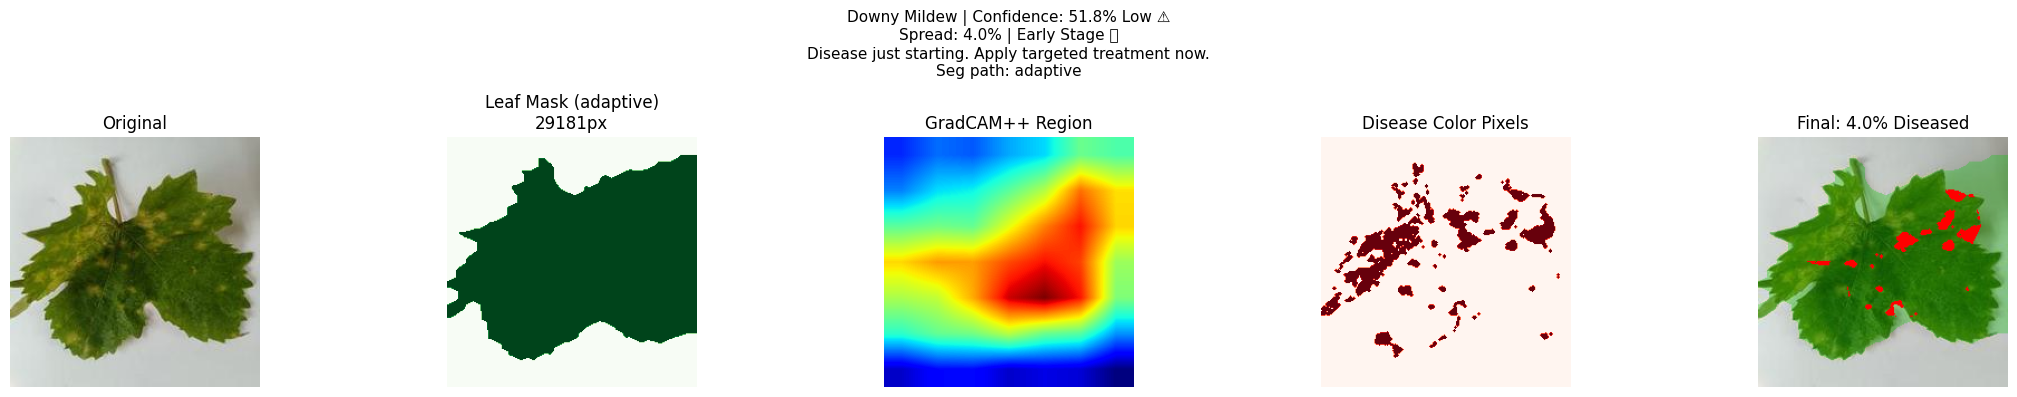


Disease    : Downy Mildew
Confidence : 51.8% — Low ⚠️
Seg path   : adaptive
Leaf pixels: 29181
Diseased px: 1176
Spread     : 4.0%
Severity   : Early Stage 🟡
Action     : Disease just starting. Apply targeted treatment now.


In [12]:
TEST_IMAGE = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/grape/Downy Mildew/Downy_Mildew_7.jpg"  # change this
disease, confidence, spread_percent, severity = calculate_accurate_spread(
    model, TEST_IMAGE, class_names, val_transform
)

## Cell 13: Test Image Example

**What:** Set a sample test image path for quick manual inference checks.

**Why:** This gives us a simple way to validate the prediction pipeline on a known example.

**Cons:** Hardcoded paths are convenient for demos but fragile across machines or folders.


/tmp/ipykernel_8648/3872366145.py:221: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


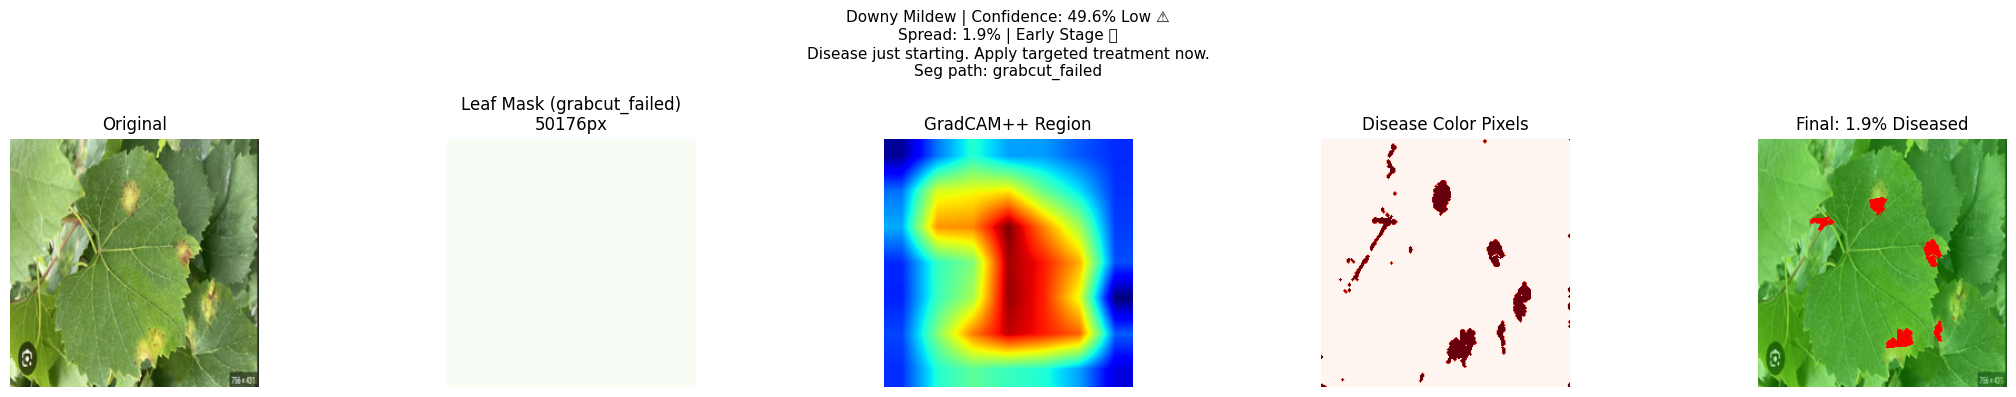


Disease    : Downy Mildew
Confidence : 49.6% — Low ⚠️
Seg path   : grabcut_failed
Leaf pixels: 50176
Diseased px: 929
Spread     : 1.9%
Severity   : Early Stage 🟡
Action     : Disease just starting. Apply targeted treatment now.


In [13]:
TEST_IMAGE = "/home/ares/Projects/Agriminds/test/Screenshot 2026-03-25 222858.png"  # change this
disease, confidence, spread_percent, severity = calculate_accurate_spread(
    model, TEST_IMAGE, class_names, val_transform
)

In [14]:
TEST_IMAGE = "/home/ares/Projects/Agriminds/Phases/FINAL-PHASE/image.png"  # change this
disease, confidence, spread_percent, severity = calculate_accurate_spread(
    model, TEST_IMAGE, class_names, val_transform
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ares/Projects/Agriminds/Phases/FINAL-PHASE/image.png'

## Done

Saved artifacts:
- grape_phase1.pt
- grape_final_model.pt
- grape_training_plot.png
- grape_confusion_matrix.png
- grape_classes.json